In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
nifty = yf.download("^NSEI", start="2018-01-01", progress=False)
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2018-01-02,10442.200195,10495.200195,10404.650391,10477.549805,153400
2018-01-03,10443.200195,10503.599609,10429.549805,10482.650391,167300
2018-01-04,10504.799805,10513.000000,10441.450195,10469.400391,174900
2018-01-05,10558.849609,10566.099609,10520.099609,10534.250000,180900
2018-01-08,10623.599609,10631.200195,10588.549805,10591.700195,169000


In [3]:
nifty = nifty.reset_index()
nifty = nifty.sort_values("Date")
nifty = nifty.set_index("Date")

In [4]:
nifty["returns"] = nifty["Close"].pct_change()

In [5]:
nifty["log_returns"] = np.log(nifty["Close"] / nifty["Close"].shift(1))

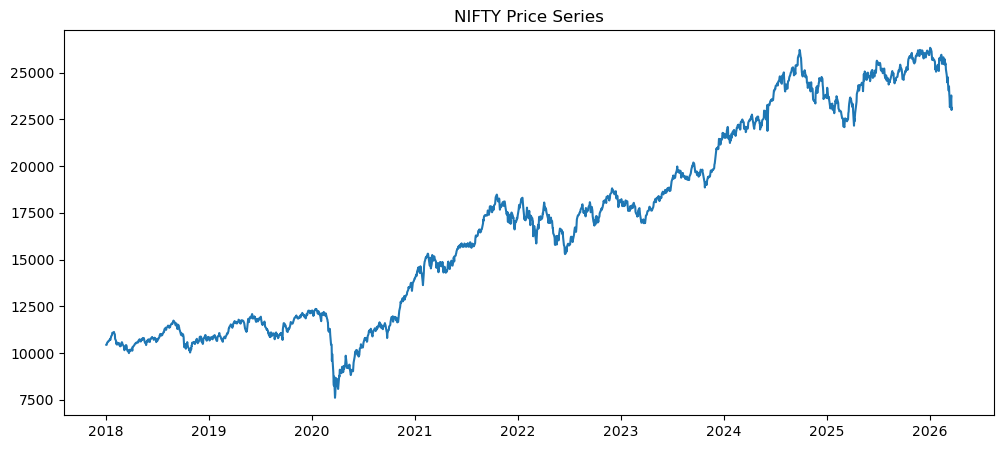

In [6]:
plt.figure(figsize=(12,5))
plt.plot(nifty.index, nifty["Close"])
plt.title("NIFTY Price Series")
plt.show()

In [7]:
nifty.to_csv("../data/nifty_base.csv")

In [8]:
nifty["volatility_20"] = nifty["returns"].rolling(20).std()

In [9]:
nifty["momentum_20"] = nifty["Close"].pct_change(20)

In [10]:
rolling_max = nifty["Close"].cummax()
nifty["drawdown"] = (nifty["Close"] - rolling_max) / rolling_max

In [11]:
nifty = nifty.dropna()

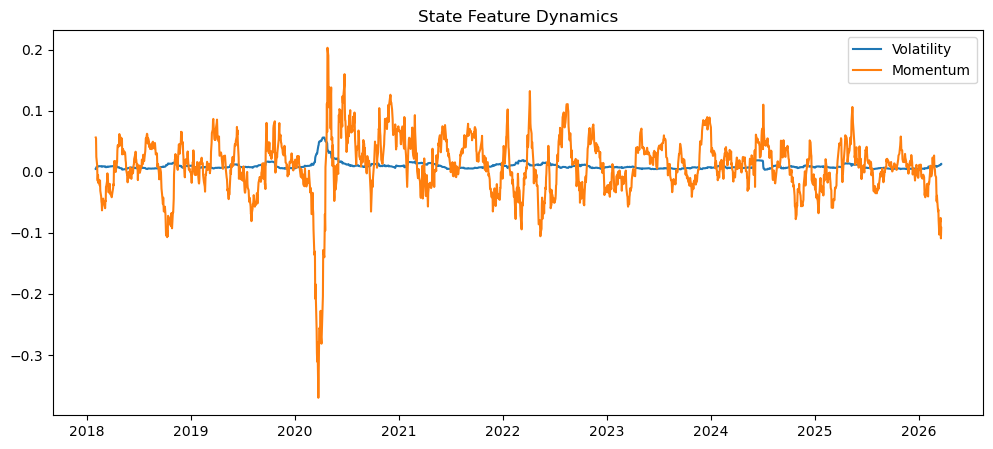

In [12]:
plt.figure(figsize=(12,5))
plt.plot(nifty.index, nifty["volatility_20"], label="Volatility")
plt.plot(nifty.index, nifty["momentum_20"], label="Momentum")
plt.legend()
plt.title("State Feature Dynamics")
plt.show()

In [13]:
nifty.to_csv("../data/nifty_features.csv")

In [16]:
nifty.columns

MultiIndex([(        'Close', '^NSEI'),
            (         'High', '^NSEI'),
            (          'Low', '^NSEI'),
            (         'Open', '^NSEI'),
            (       'Volume', '^NSEI'),
            (      'returns',      ''),
            (  'log_returns',      ''),
            ('volatility_20',      ''),
            (  'momentum_20',      ''),
            (     'drawdown',      '')],
           names=['Price', 'Ticker'])